# 09 · Recorded results and null floors

Recorded scores for four capabilities, each shown against its matched null floor and,
where one exists, a ceiling. Evaluated models appear as bars. **Controls**, meaning
chance and random-feature baselines, define the floor, and an **oracle** defines the
ceiling; neither is a model, so both are drawn as reference lines. Model sets and metrics
differ between panels, so comparisons are valid only within a panel.

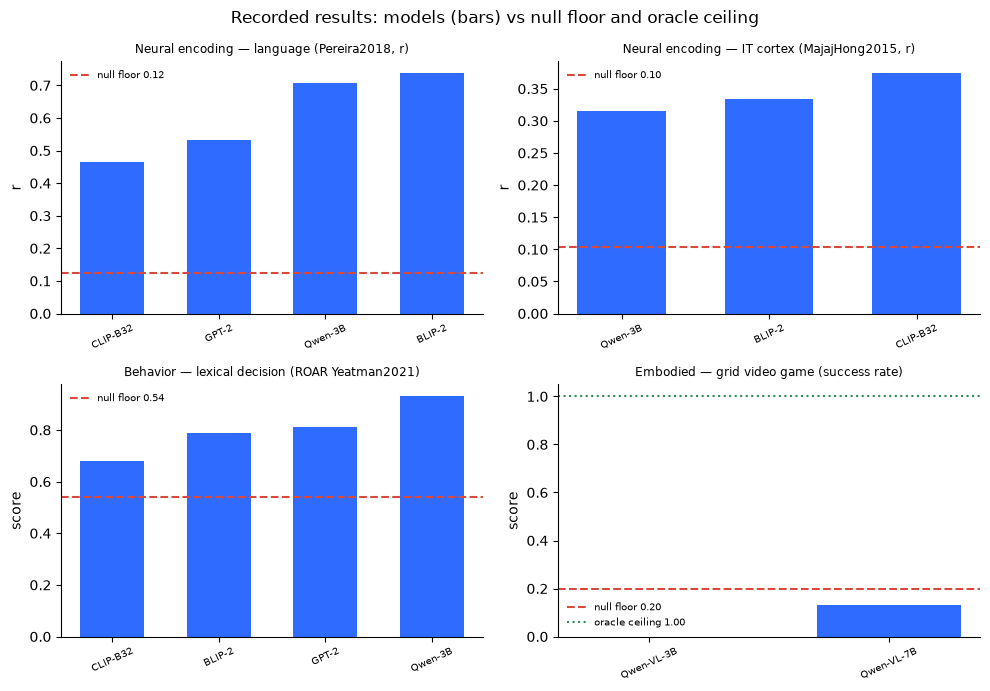

language_encoding  best model BLIP-2 = 0.74 | null 0.12
it_encoding        best model CLIP-B32 = 0.37 | null 0.10
behavior_roar      best model Qwen-3B = 0.93 | null 0.54
embodied_game      best model Qwen-VL-7B = 0.13 | null 0.20 | oracle 1.00


In [1]:
import warnings; warnings.filterwarnings('ignore')
import json
from pathlib import Path
import matplotlib.pyplot as plt

# Recorded scores ship alongside this notebook, so it runs from anywhere.
# Search a few locations relative to BOTH this file and the working directory,
# and fail with a readable message rather than a bare StopIteration.
_here = Path.cwd()
candidates = [_here / 'data' / 'results.json',
              _here / 'notebooks' / 'data' / 'results.json',
              _here / 'unified' / 'notebooks' / 'data' / 'results.json',
              _here.parent / 'notebooks' / 'data' / 'results.json']
path = next((p for p in candidates if p.exists()), None)
if path is None:
    raise FileNotFoundError(
        'Could not find results.json. It should sit at notebooks/data/results.json. '
        'Looked in:\n  ' + '\n  '.join(str(p) for p in candidates))
record = json.loads(path.read_text())

# The four capabilities to show, one per panel.
selected = ['language_encoding', 'it_encoding', 'behavior_roar', 'embodied_game']

CONTROLS = {'chance', 'random', 'random-vit'}   # floor references, not models
CEILING = {'oracle'}                            # upper reference, not a model

# One panel per capability: evaluated models as bars, plus a null-floor line and (if present) an oracle-ceiling line.
fig, axes = plt.subplots(2, 2, figsize=(10, 7))
for ax, key in zip(axes.ravel(), selected):
    item = record['scaling'][key]
    unit = item['capability'].split(',')[-1].strip(' )') if ',' in item['capability'] else 'score'
    pairs = list(zip(item['models'], item['scores']))
    # Keep only real models as bars; controls and the oracle are drawn as reference lines, not bars.
    models = [(m, s) for m, s in pairs if m not in CONTROLS | CEILING]
    ceil = next((s for m, s in pairs if m in CEILING), None)
    ax.bar([m for m, _ in models], [s for _, s in models], color='#2f6bff', width=0.6)
    ax.axhline(item['null_floor'], color='#d8483b', ls='--', label=f"null floor {item['null_floor']:.2f}")
    if ceil is not None:
        ax.axhline(ceil, color='#2e8b57', ls=':', label=f'oracle ceiling {ceil:.2f}')
    ax.set_title(item['capability'], fontsize=8.5)
    ax.set_ylabel(unit); ax.tick_params(axis='x', rotation=25, labelsize=7)
    ax.spines[['top', 'right']].set_visible(False); ax.legend(frameon=False, fontsize=7)
fig.suptitle('Recorded results: models (bars) vs null floor and oracle ceiling')
fig.tight_layout(); plt.show()

# Print the best model per panel next to its null floor (and oracle ceiling, where one exists).
for key in selected:
    item = record['scaling'][key]
    pairs = list(zip(item['models'], item['scores']))
    models = [(m, s) for m, s in pairs if m not in CONTROLS | CEILING]
    best_m, best_s = max(models, key=lambda t: t[1])
    ceil = next((s for m, s in pairs if m in CEILING), None)
    print(f"{key:18s} best model {best_m} = {best_s:.2f} | null {item['null_floor']:.2f}"
          + (f" | oracle {ceil:.2f}" if ceil is not None else ''))

**Interpretation.** Each bar is one evaluated model, and a result counts only if it
exceeds the red null-floor line. Neural encoding and behavior clear their nulls. The
embodied grid game does not: its best VLM falls below the null. The green line is the
oracle ceiling, a perfect player, rather than a model. Comparisons remain valid only
within a panel.